In [30]:
using CSV
using CUDA
using DataFrames
using HDF5
using ITensorMPS
using ITensors
using ITensors:cpu
using Printf
using Plots

In [31]:
g = 0.5
N = 128 
d = 50

j = 1.1
formatted_j = @sprintf("%.4f", j)
delta = 1.0


gs = repeat([g*π], N)
jz = rand(-π:π, N)
jzz = rand(-1.5π:-0.5π, N-1)

emb = []
f = h5open("MPS/eSSH/N128_p_p/$(delta)/$(formatted_j).h5", "r")
psi = read(f, "psi", MPS)
sites = siteinds(psi)
zs = expect(psi, "Z")
zzcorr = correlation_matrix(psi, "Z", "Z")
zzs = [zzcorr[i, i+1] for i in 1:N-1]
push!(emb, vcat(zs, zzs))

rx_gates = [op("Rx", sites[n], θ=gs[n]) for n in 1:N]
rz_gates = [op("Rz", sites[n], θ=jz[n]) for n in 1:N]
jzz_gates = [op("Rzz", sites[n], sites[n+1], ϕ=jzz[n]) for n in 1:N-1]
singlayer = vcat(rx_gates,  jzz_gates, rz_gates)

for i in 1:d
    psi = apply(singlayer, psi, cutoff=1e-8)
    normalize!(psi)
    zs = expect(psi, "Z")
    zzcorr = correlation_matrix(psi, "Z", "Z")
    zzs = [zzcorr[i, i+1] for i in 1:N-1]
    push!(emb, vcat(zs, zzs))
end
emb = real(hcat(emb...))

InterruptException: InterruptException:

In [32]:
default(size=(340, 250))  # 约8.6cm x 6.3cm，适合revtex双栏单栏
plt = heatmap(
    0:50,                     # 横轴 t
    1:255,                    # 纵轴 index (1:128 Z, 129:255 ZZ)
    real.(emb),               # 数据矩阵
    clim=(-1,1),              # 颜色范围
    color=:thermal,
    xlabel="D cycles",
    ylabel="local expectations",
    framestyle=:semi, tick_direction=:out, colorbar=false
)
savefig(plt, "./dynamical/heatmap_g_$(g)_($(delta),$(formatted_j)).pdf")
plt

MethodError: MethodError: no method matching heatmap_edges(::UnitRange{Int64}, ::Symbol, ::UnitRange{Int64}, ::Symbol, ::Tuple{Int64}, ::Bool)
The function `heatmap_edges` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  heatmap_edges(::AbstractVector, ::Symbol, ::AbstractVector, ::Symbol, !Matched::Tuple{Int64, Int64}, ::Bool)
   @ Plots ~/.julia/packages/Plots/bpxfB/src/utils.jl:269
  heatmap_edges(::AbstractVector, ::Symbol, ::AbstractVector, ::Symbol, !Matched::Tuple{Int64, Int64})
   @ Plots ~/.julia/packages/Plots/bpxfB/src/utils.jl:269
  heatmap_edges(::AbstractVector, ::Symbol, !Matched::Bool, !Matched::Bool)
   @ Plots ~/.julia/packages/Plots/bpxfB/src/utils.jl:262
  ...


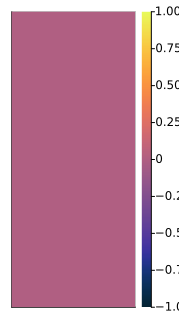

In [45]:
using Plots
default(size=(180, 320))  # 画布尺寸不变
plt = heatmap([0 0; 0 0], clim=(-1,1), color=:thermal, framestyle=:semi, tick_direction=:out, xlabel="", ylabel="", xticks=false, yticks=false, colorbar=true, colorbar_title="", colorbar_ticks=([-1,0,1], ["-1","0","1"]), colorbar_tickfontsize=18, colorbar_thickness=60, colorbar_titlefontsize=1, colorbar_pad=30)
display(plt)

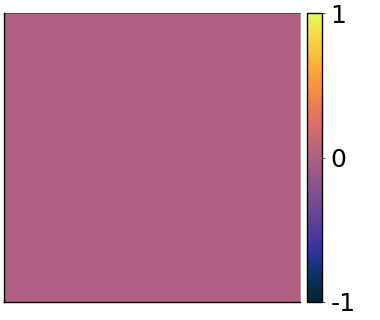

In [ ]:
using Plots
pyplot()
default(size=(380, 320))
plt = heatmap(
    [0 0; 0 0],
    clim=(-1,1),
    color=:thermal,
    framestyle=:semi,
    tick_direction=:out,
    xlabel="",
    ylabel="",
    xticks=false,
    yticks=false,
    colorbar=true,
    colorbar_title="",
    colorbar_ticks=([-1,0,1], ["-1","0","1"]),
    colorbar_tickfontsize=18,
    colorbar_thickness=100,
    colorbar_titlefontsize=1,
    colorbar_pad=80  # 增大色条与图片的间距
    )
display(plt)

In [27]:
g = 0.96
N = 128 
d = 50
g = repeat([g*π], N)
jz = rand(-π:π, N)
jzz = rand(-1.5π:-0.5π, N-1)

emb = []
f = h5open("MPS/eSSH/N128_p_p/0.0/3.0000.h5", "r")
psi = read(f, "psi", MPS)
sites = siteinds(psi)
zs = expect(psi, "Z")
zzcorr = correlation_matrix(psi, "Z", "Z")
zzs = [zzcorr[i, i+1] for i in 1:N-1]
push!(emb, vcat(zs, zzs))

rx_gates = [op("Rx", sites[n], θ=g[n]) for n in 1:N]
rz_gates = [op("Rz", sites[n], θ=jz[n]) for n in 1:N]
jzz_gates = [op("Rzz", sites[n], sites[n+1], ϕ=jzz[n]) for n in 1:N-1]
singlayer = vcat(rx_gates,  jzz_gates, rz_gates)

for i in 1:d
    psi = apply(singlayer, psi, cutoff=1e-8)
    normalize!(psi)
    zs = expect(psi, "Z")
    zzcorr = correlation_matrix(psi, "Z", "Z")
    zzs = [zzcorr[i, i+1] for i in 1:N-1]
    push!(emb, vcat(zs, zzs))
end
emb = real(hcat(emb...))
plt = heatmap(
    0:50,                     # 横轴 t
    1:255,                    # 纵轴 index (1:128 Z, 129:255 ZZ)
    real.(emb),                      # 数据矩阵
    clim=(-1,1),              # 颜色范围
    color=:thermal,
    xlabel="time step",
    ylabel="observable index",
    title="g = 0.96, topo state"
)
savefig(plt, "./dynamical/heatmap_g_0.96_topo_state.png")
show(plt)

Plot{Plots.GRBackend() n=1}

In [28]:
g = 0.84
N = 128 
d = 50
g = repeat([g*π], N)
jz = rand(-π:π, N)
jzz = rand(-1.5π:-0.5π, N-1)

emb = []
f = h5open("MPS/eSSH/N128_p_p/0.0/3.0000.h5", "r")
psi = read(f, "psi", MPS)
sites = siteinds(psi)
zs = expect(psi, "Z")
zzcorr = correlation_matrix(psi, "Z", "Z")
zzs = [zzcorr[i, i+1] for i in 1:N-1]
push!(emb, vcat(zs, zzs))

rx_gates = [op("Rx", sites[n], θ=g[n]) for n in 1:N]
rz_gates = [op("Rz", sites[n], θ=jz[n]) for n in 1:N]
jzz_gates = [op("Rzz", sites[n], sites[n+1], ϕ=jzz[n]) for n in 1:N-1]
singlayer = vcat(rx_gates,  jzz_gates, rz_gates)

for i in 1:d
    psi = apply(singlayer, psi, cutoff=1e-8)
    normalize!(psi)
    zs = expect(psi, "Z")
    zzcorr = correlation_matrix(psi, "Z", "Z")
    zzs = [zzcorr[i, i+1] for i in 1:N-1]
    push!(emb, vcat(zs, zzs))
end
emb = real(hcat(emb...))
plt = heatmap(
    0:50,                     # 横轴 t
    1:255,                    # 纵轴 index (1:128 Z, 129:255 ZZ)
    real.(emb),                      # 数据矩阵
    clim=(-1,1),              # 颜色范围
    color=:thermal,
    xlabel="time step",
    ylabel="observable index",
    title="g = 0.84, topo state"
)
savefig(plt, "./dynamical/heatmap_g_0.84_topo_state.png")
show(plt)

Plot{Plots.GRBackend() n=1}